M shape: (2, 3)
U shape: (2, 2) — autovetores de MMᵀ
s shape: (2,) — valores singulares
Vt shape: (3, 3) — autovetores de MᵀM (transpostos)

Valores singulares σ: [5. 3.]

Reconstrução M = UΣVᵀ:
[[ 3.  2.  2.]
 [ 2.  3. -2.]]
Idêntica ao original? True

σ derivado de MᵀM: [5. 3.]
σ do numpy:        [5. 3.]
rank-1: 73.5% da energia
rank-2: 100.0% da energia

Imagem: (120, 160), rank original = 120
rank-  1: erro=0.2176, params=   281, compressão=68.3x
rank-  3: erro=0.0938, params=   843, compressão=22.8x
rank-  5: erro=0.0911, params=  1405, compressão=13.7x
rank- 10: erro=0.0851, params=  2810, compressão=6.8x
rank- 20: erro=0.0740, params=  5620, compressão=3.4x
rank- 50: erro=0.0457, params= 14050, compressão=1.4x

Sistema sobredeterminado Ax=b:
x (mínimos quadrados via SVD): [1.11022302e-16 5.00000000e-01]
x (numpy lstsq):               [-5.97106181e-17  5.00000000e-01]


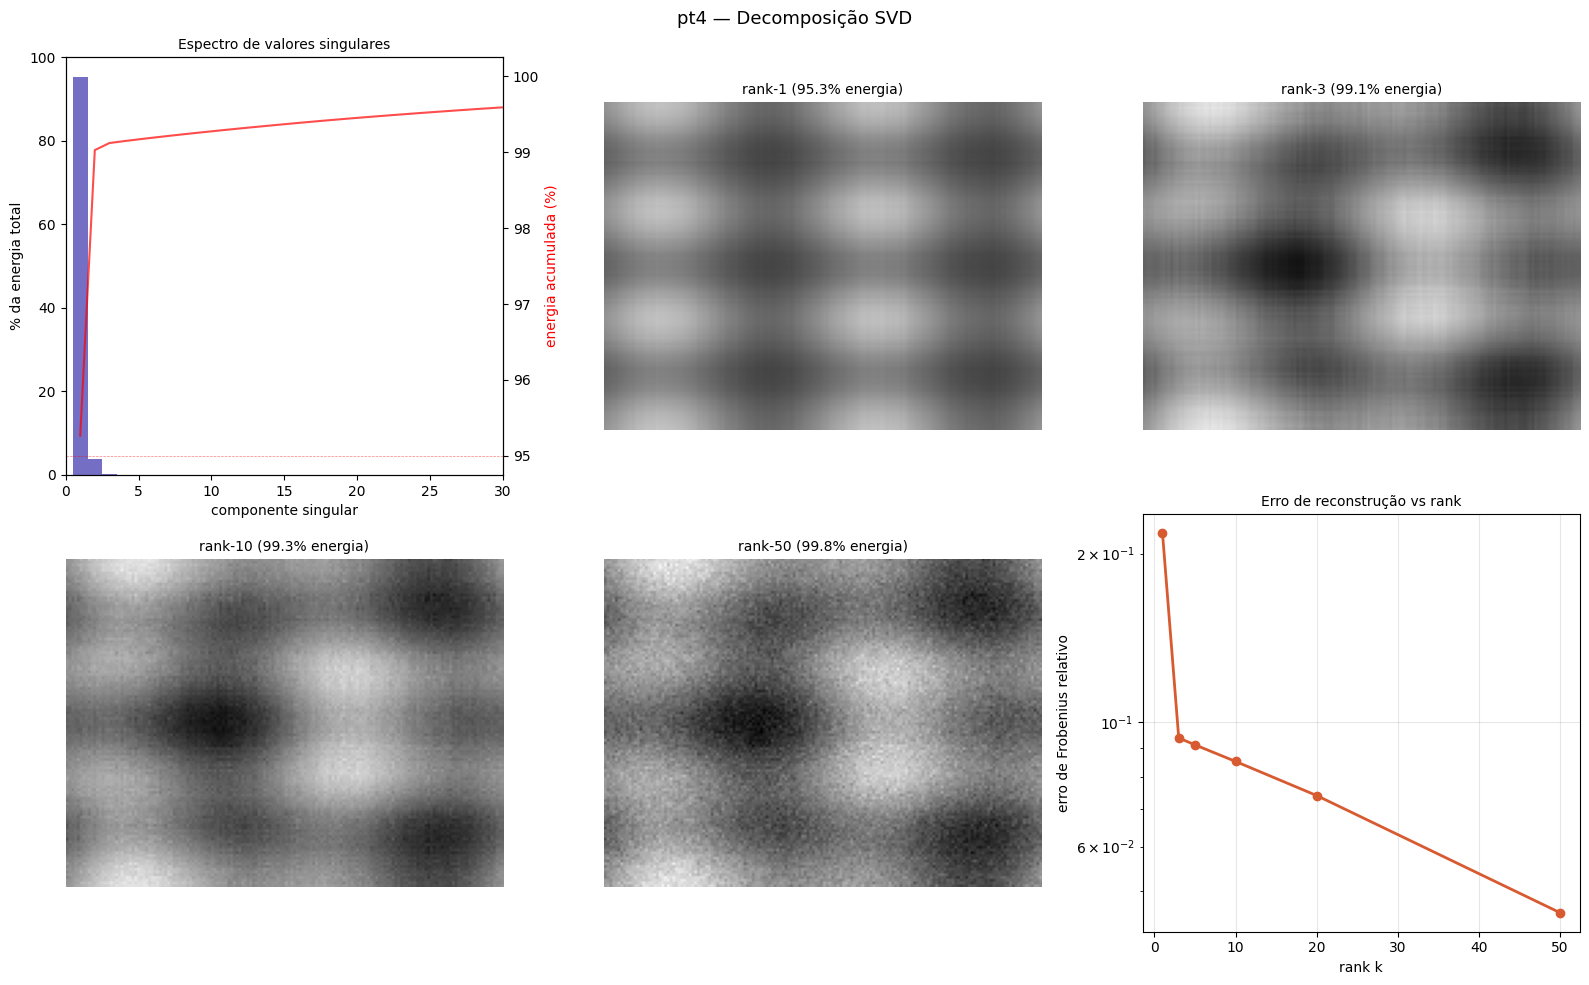


✓ Commit 04 completo.


In [ ]:

# a parte 3 mostrou que matrizes simétricas quadradas têm
# decomposição M = V Λ Vᵀ. Mas e matrizes não-quadradas?
# Dados reais têm shape (n_amostras, n_features) — raramente quadradas.

# SVD resolve isso: qualquer matriz M (m×n) pode ser decomposta em

#   M = U Σ Vᵀ

# onde:
#   U  (m×m) — autovetores de MMᵀ (relações entre amostras)
#   Σ  (m×n) — diagonal de valores singulares σᵢ = √λᵢ ≥ 0
#   Vᵀ (n×n) — autovetores de MᵀM (relações entre features)

# Interpretação geométrica:
#   Vᵀ → rotação no espaço das features
#   Σ  → escala em cada dimensão
#   U  → rotação no espaço das amostras

# Qualquer transformação linear é: rotaciona → estica → rotaciona.

# Conexão com eigendecomposição:
#   MᵀM = (UΣVᵀ)ᵀ(UΣVᵀ) = VΣᵀUᵀUΣVᵀ = VΣ²Vᵀ
#   Logo, colunas de V = autovetores de MᵀM
#   σᵢ = √(autovalor_i de MᵀM)

# Rank e informação:
#   O rank de M = número de valores singulares não-nulos.
#   SVD truncada: manter só os k maiores σᵢ → aproximação de rank k.
#   Essa aproximação é ÓTIMA (teorema de Eckart-Young).


import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import urllib.request
import os


# pt 1 — SVD de uma matriz simples, tudo na mão


M = np.array([[3., 2., 2.],
              [2., 3., -2.]])   # matriz 2×3, não-quadrada

# numpy computa SVD
U, s, Vt = np.linalg.svd(M, full_matrices=True)

print("M shape:", M.shape)
print("U shape:", U.shape, "— autovetores de MMᵀ")
print("s shape:", s.shape, "— valores singulares")
print("Vt shape:", Vt.shape, "— autovetores de MᵀM (transpostos)")
print("\nValores singulares σ:", s)

# reconstrução: precisamos montar Σ com zeros
Sigma = np.zeros(M.shape)
Sigma[:len(s), :len(s)] = np.diag(s)

M_rec = U @ Sigma @ Vt
print(f"\nReconstrução M = UΣVᵀ:")
print(np.round(M_rec, 6))
print(f"Idêntica ao original? {np.allclose(M, M_rec)}")


# pt2 — Derivando SVD a partir de eigendecomposição

# Vamos calcular SVD manualmente via MᵀM e MMᵀ

MtM = M.T @ M          # 3×3 — autovetores = colunas de V
MMt = M @ M.T          # 2×2 — autovetores = colunas de U

# eigendecomposição de MᵀM
vals_v, V_manual = np.linalg.eigh(MtM)
# ordenar decrescente (eigh retorna crescente)
idx = np.argsort(vals_v)[::-1]
vals_v = vals_v[idx]
V_manual = V_manual[:, idx]

# valores singulares
sigma_manual = np.sqrt(np.maximum(vals_v[:2], 0))  # máx 0 para evitar sqrt(-ε)
print(f"\nσ derivado de MᵀM: {sigma_manual}")
print(f"σ do numpy:        {s}")


# pt3 — Aproximação de baixo rank


# A grande aplicação do SVD: comprimir uma matriz mantendo
# os k componentes mais importantes.
#
# M ≈ σ₁ u₁v₁ᵀ + σ₂ u₂v₂ᵀ + ... + σₖ uₖvₖᵀ
#
# Cada termo σᵢ uᵢvᵢᵀ é uma matriz de rank 1 (produto externo).
# A soma dos primeiros k termos captura max informação possível
# com k parâmetros — isso é o teorema de Eckart-Young.

def svd_rank_k(U, s, Vt, k):
    """Reconstrói M usando apenas os k maiores valores singulares."""
    return U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]

# quanto de "energia" (variância) cada componente explica
energia_total = np.sum(s**2)
for k in range(1, len(s)+1):
    energia_k = np.sum(s[:k]**2)
    print(f"rank-{k}: {100*energia_k/energia_total:.1f}% da energia")


#pt3 — APLICAÇÃO REAL: compressão de imagem com SVD

# Uma imagem em escala de cinza é uma matriz (altura × largura).
# SVD encontra a estrutura mais importante e descarta ruído.

# Criando uma imagem sintética com estrutura (não depende de download)
altura, largura = 120, 160

# imagem com padrões: gradiente + formas geométricas
x = np.linspace(0, 2*np.pi, largura)
y = np.linspace(0, 2*np.pi, altura)
XX, YY = np.meshgrid(x, y)

img = (
    0.4 * np.sin(XX) * np.cos(YY) +
    0.3 * np.sin(2*XX) +
    0.2 * np.cos(3*YY) +
    0.1 * np.random.randn(altura, largura)
)
# normalizar para [0, 1]
img = (img - img.min()) / (img.max() - img.min())

print(f"\nImagem: {img.shape}, rank original = {np.linalg.matrix_rank(img)}")

# SVD da imagem
U_img, s_img, Vt_img = np.linalg.svd(img, full_matrices=False)

# Erros de reconstrução por rank
ranks_teste = [1, 3, 5, 10, 20, 50]
erros = []
for k in ranks_teste:
    img_k = svd_rank_k(U_img, s_img, Vt_img, k)
    erro = np.linalg.norm(img - img_k, 'fro') / np.linalg.norm(img, 'fro')
    erros.append(erro)
    n_params = k * (altura + largura + 1)
    compressao = (altura * largura) / n_params
    print(f"rank-{k:3d}: erro={erro:.4f}, params={n_params:6d}, compressão={compressao:.1f}x")

# pt5 — SVD e Pseudoinversa

# M⁺ = V Σ⁺ Uᵀ  onde Σ⁺ inverte só os σ não-nulos
#
# Isso resolve sistemas Ax = b no sentido de mínimos quadrados
# mesmo quando A não é quadrada ou é singular.
# É a base da regressão linear (solução pela equação normal).

def pseudoinversa(U, s, Vt, tol=1e-10):
    """Pseudoinversa via SVD."""
    s_inv = np.where(s > tol, 1.0/s, 0.0)
    return Vt.T @ np.diag(s_inv) @ U.T

A = np.array([[1., 2.],
              [3., 4.],
              [5., 6.]])
b = np.array([1., 2., 3.])

U_a, s_a, Vt_a = np.linalg.svd(A, full_matrices=False)
A_plus = pseudoinversa(U_a, s_a, Vt_a)
x_sol = A_plus @ b

print(f"\nSistema sobredeterminado Ax=b:")
print(f"x (mínimos quadrados via SVD): {x_sol}")
print(f"x (numpy lstsq):               {np.linalg.lstsq(A, b, rcond=None)[0]}")


# pt6  — VISUALIZAÇÃO


fig = plt.figure(figsize=(16, 10))
fig.suptitle("pt4 — Decomposição SVD", fontsize=13)

# Plot 1: valores singulares (espectro)
ax1 = fig.add_subplot(2, 3, 1)
ax1.bar(range(1, len(s_img)+1), s_img**2 / np.sum(s_img**2) * 100,
        color='#534AB7', alpha=0.8, width=1.0)
ax1.set_xlabel("componente singular")
ax1.set_ylabel("% da energia total")
ax1.set_title("Espectro de valores singulares", fontsize=10)
ax1.set_xlim(0, 30)

energia_acum = np.cumsum(s_img**2) / np.sum(s_img**2) * 100
ax1b = ax1.twinx()
ax1b.plot(range(1, len(s_img)+1), energia_acum, 'r-', lw=1.5, alpha=0.7)
ax1b.set_ylabel("energia acumulada (%)", color='red')
ax1b.axhline(95, color='red', lw=0.5, linestyle='--', alpha=0.5)
ax1b.set_xlim(0, 30)

# Plots 2-5: reconstruções com diferentes ranks
ranks_plot = [1, 3, 10, 50]
for i, k in enumerate(ranks_plot):
    ax = fig.add_subplot(2, 3, i+2)
    img_k = svd_rank_k(U_img, s_img, Vt_img, k)
    img_k = np.clip(img_k, 0, 1)
    ax.imshow(img_k, cmap='gray', vmin=0, vmax=1)
    energia = 100*np.sum(s_img[:k]**2)/np.sum(s_img**2)
    ax.set_title(f"rank-{k} ({energia:.1f}% energia)", fontsize=10)
    ax.axis('off')

# Plot 6: erro vs rank
ax6 = fig.add_subplot(2, 3, 6)
ax6.plot(ranks_teste, erros, 'o-', color='#D85A30', lw=2, ms=6)
ax6.set_xlabel("rank k")
ax6.set_ylabel("erro de Frobenius relativo")
ax6.set_title("Erro de reconstrução vs rank", fontsize=10)
ax6.grid(True, alpha=0.3)
ax6.set_yscale('log')

plt.tight_layout()
#plt.savefig('../assets/04_svd.png', dpi=150, bbox_inches='tight')
plt.show()



